# attrib-EDITS · edits_l3 — the gradient counterfactual direction

Where *should* we edit? The gradient of the predictor's score w.r.t. the input embeddings gives a per-position sensitivity — the continuous cousin of the discrete search, and the natural place to plug in **Integrated Gradients** (see [`common/ig_l1`](../common/ig_l1_simple.ipynb)).

In [1]:
import os, sys
ROOT = os.path.abspath("")
while ROOT != os.path.dirname(ROOT) and not os.path.isdir(os.path.join(ROOT, "common")):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)                          # for `import common`
sys.path.insert(0, os.path.join(ROOT, "edits"))   # for `import edits_common`
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\xai-starter


In [2]:
import numpy as np
from edits_common import DEMO_SEQ, gradient_saliency
sal = gradient_saliency(DEMO_SEQ)
top = np.argsort(sal)[::-1][:8]
print('most sensitive positions:', [(int(i), DEMO_SEQ[i]) for i in top])

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

most sensitive positions: [(28, 'V'), (42, 'W'), (26, 'E'), (29, 'F'), (53, 'V'), (10, 'T'), (0, 'M'), (8, 'G')]


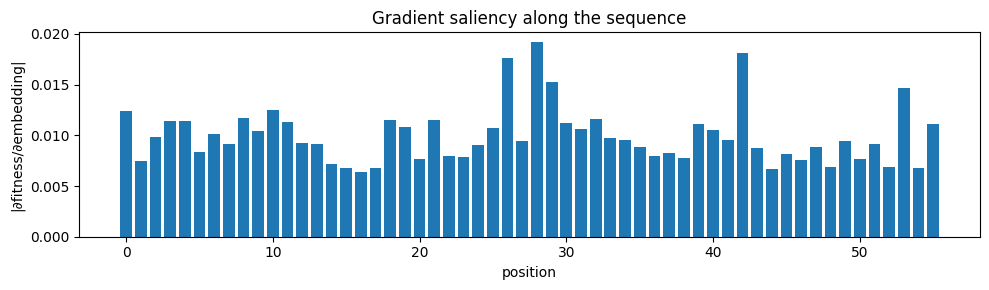

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.bar(range(len(sal)), sal)
plt.xlabel('position'); plt.ylabel('|∂fitness/∂embedding|')
plt.title('Gradient saliency along the sequence'); plt.tight_layout(); plt.show()

### Things to experiment with
- Do the high-saliency positions overlap the edits picked in edits_l2?
- Replace the raw gradient with Captum Integrated Gradients for a baseline-anchored attribution.